# Telekom Müşteri Kaybı (Churn) Tahmin Modeli

Bu not defteri, bir telekom şirketinin müşteri verilerini kullanarak müşteri kaybını (churn) tahmin eden bir makine öğrenmesi projesi sunmaktadır. Proje, Lojistik Regresyon ve Random Forest modellerini karşılaştırmaktadır.

## Adım 1: Ortam Kurulumu ve Kütüphanelerin Yüklenmesi

Projemizde kullanacağımız temel veri analizi, görselleştirme ve makine öğrenmesi kütüphanelerini import edelim.

In [1]:
# Gerekli kütüphaneleri import et
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarlarını yapılandır
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Tüm kütüphaneler başarıyla yüklendi.')

Tüm kütüphaneler başarıyla yüklendi.


## Adım 2: Veri Setinin Yüklenmesi ve İlk Analiz

IBM Telco Customer Churn veri setini yükleyelim ve ilk keşifleri yapalım.

In [2]:
# Veri setini yükle
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print('Veri seti şekli:', df.shape)
print('\nİlk 5 satır:')
print(df.head())

Veri seti şekli: (7043, 21)

İlk 5 satır:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Stream

In [8]:
# Veri setinin yapısını incele
print('Veri Seti Bilgileri:')
print(df.info())
print('\nÖzet İstatistikler:')
print(df.describe())

Veri Seti Bilgileri:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non

## Adım 3: Keşifsel Veri Analizi (EDA) ve Veri Ön İşleme

### 3.1: Eksik Veri Tespiti ve Temizleme

In [3]:
# Eksik verileri kontrol et
print('Eksik veri sayıları:')
print(df.isnull().sum())

# TotalCharges sütununda boşluk karakteri olup olmadığını kontrol et
print('\nTotalCharges veri tipi:', df['TotalCharges'].dtype)
print('Boşluk içeren satır sayısı:', (df['TotalCharges'] == ' ').sum())

# Boşluk içeren satırları kaldır
df = df[df['TotalCharges'] != ' ']

# TotalCharges'ı sayısal türe dönüştür
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print('\nSonrası veri seti şekli:', df.shape)
print('TotalCharges veri tipi:', df['TotalCharges'].dtype)

Eksik veri sayıları:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges veri tipi: object
Boşluk içeren satır sayısı: 11

Sonrası veri seti şekli: (7032, 21)
TotalCharges veri tipi: float64


### 3.2: Hedef Değişken Analizi (Churn)

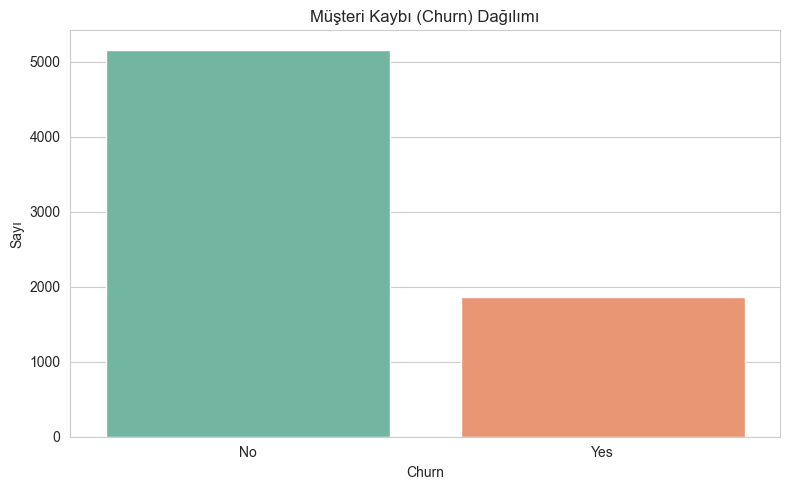

Churn Oranı:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [4]:
# Churn dağılımını görselleştir
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Müşteri Kaybı (Churn) Dağılımı')
plt.xlabel('Churn')
plt.ylabel('Sayı')
plt.tight_layout()
plt.show()

# Churn oranını hesapla
churn_ratio = df['Churn'].value_counts(normalize=True) * 100
print('Churn Oranı:')
print(churn_ratio)

### 3.3: Kategorik ve Sayısal Değişkenlerin Ayrıştırılması

In [7]:
# customerID'yi sil
df = df.drop(columns=['customerID'])

# Churn hedef değişkendir
target = 'Churn'

# Kategorik ve sayısal sütunları ayır
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Hedef değişkeni listelerden çıkar
if target in categorical_cols:
    categorical_cols.remove(target)
if target in numerical_cols:
    numerical_cols.remove(target)

print('Kategorik Sütunlar:', categorical_cols)
print('\nSayısal Sütunlar:', numerical_cols)

Kategorik Sütunlar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Sayısal Sütunlar: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


### 3.4: Veri Görselleştirme

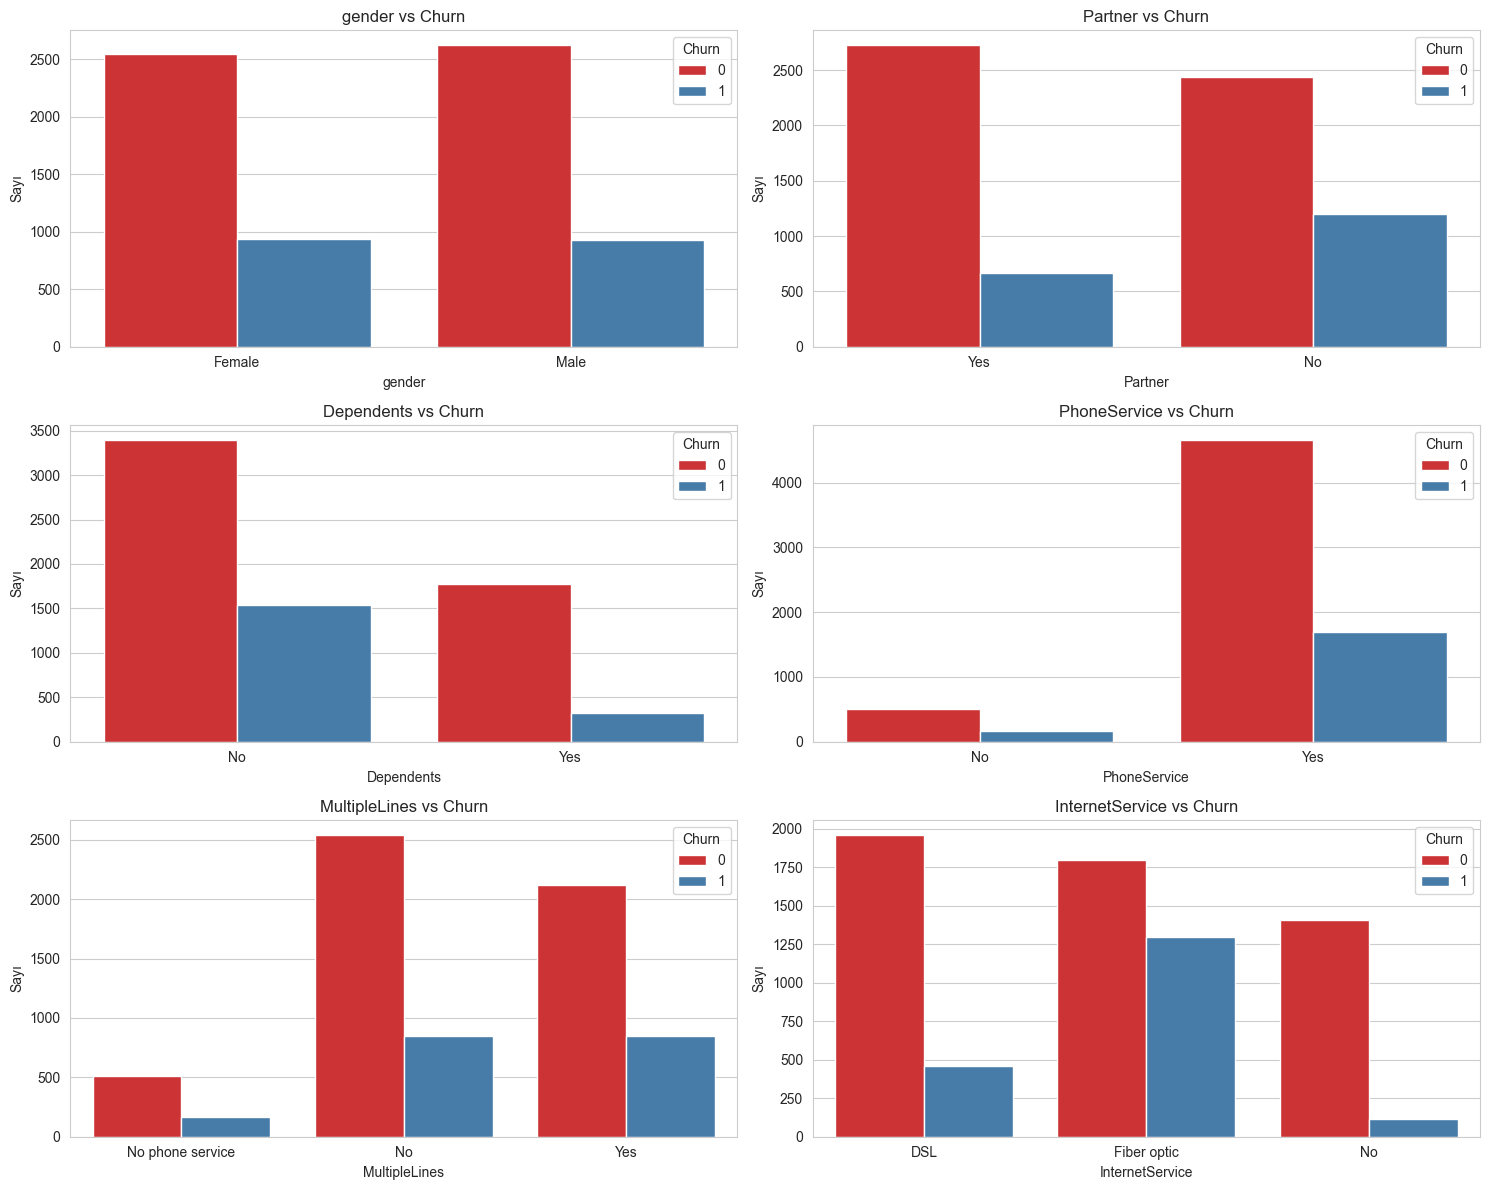

In [12]:
# Kategorik değişkenlerin Churn üzerine etkisini görselleştir (örnek: ilk 6 kategorik sütun)
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols[:6]):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[idx], palette='Set1')
    axes[idx].set_title(f'{col} vs Churn')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Sayı')

plt.tight_layout()
plt.show()

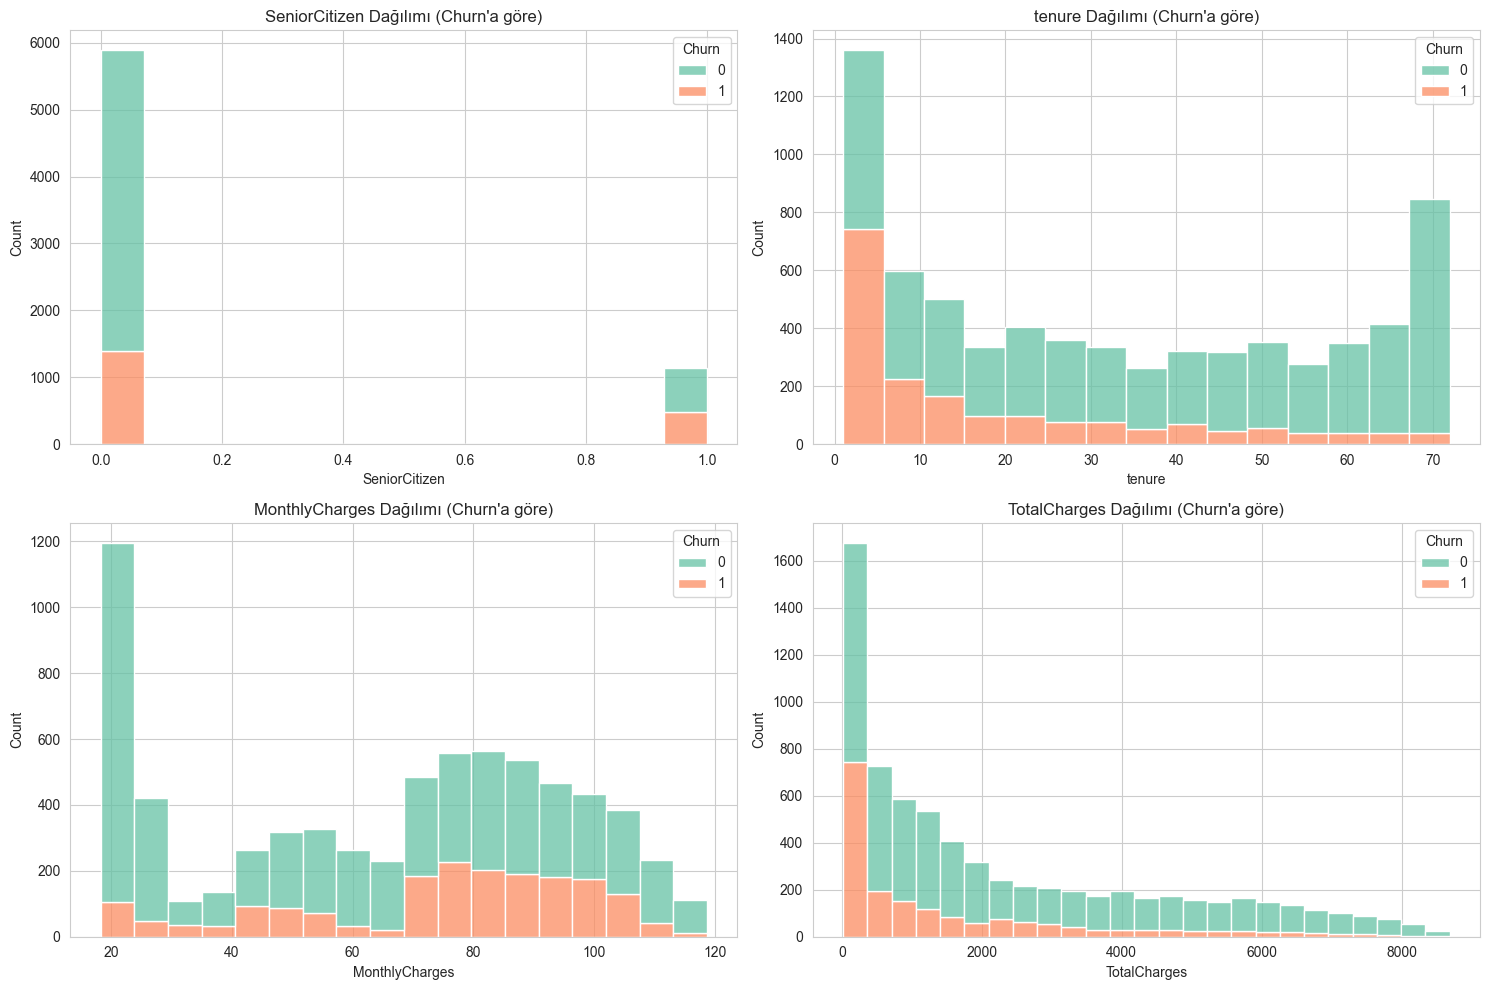

In [22]:
# Sayısal değişkenlerin Churn'e göre dağılımını görselleştir
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Churn', multiple='stack', ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} Dağılımı (Churn\'a göre)')
    axes[idx].set_xlabel(col)

plt.tight_layout()
plt.show()

## Adım 4: Özellik Mühendisliği (Feature Engineering) ve Veri Hazırlığı

### 4.1: Hedef Değişkeni Kodlama

In [5]:
# Churn'ü sayısal forma dönüştür: 'No'=0, 'Yes'=1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print('Churn değerleri:')
print(df['Churn'].unique())
print('\nChurn dağılımı:')
print(df['Churn'].value_counts())

Churn değerleri:
[0 1]

Churn dağılımı:
Churn
0    5163
1    1869
Name: count, dtype: int64


### 4.2: Ön İşleme Pipeline'ı Oluşturma

In [9]:
# Ön işleme pipeline'ı oluştur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

print('Ön işleme pipeline\'ı başarıyla oluşturuldu.')
print('Sayısal sütunlar StandardScaler ile normalize edilecek.')
print('Kategorik sütunlar OneHotEncoder ile dönüştürülecek.')

Ön işleme pipeline'ı başarıyla oluşturuldu.
Sayısal sütunlar StandardScaler ile normalize edilecek.
Kategorik sütunlar OneHotEncoder ile dönüştürülecek.


## Adım 5: Veri Setini Eğitim ve Test Olarak Ayırma

In [10]:
# Özellik matrisini ve hedef vektörü tanımla
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-test split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Eğitim seti boyutu: {X_train.shape}')
print(f'Test seti boyutu: {X_test.shape}')
print(f'\nEğitim setinde Churn oranı: {y_train.value_counts(normalize=True)}')
print(f'\nTest setinde Churn oranı: {y_test.value_counts(normalize=True)}')

Eğitim seti boyutu: (5625, 19)
Test seti boyutu: (1407, 19)

Eğitim setinde Churn oranı: Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Test setinde Churn oranı: Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


## Adım 6: Model Oluşturma, Eğitme ve Değerlendirme

### 6.1: Lojistik Regresyon Modeli

In [11]:
# Lojistik Regresyon Pipeline'ı oluştur
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Eğitim verisiyle eğit
lr_pipeline.fit(X_train, y_train)

# Test verisi üzerinde tahmin yap
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print('Lojistik Regresyon modeli eğitilmiş ve tahmin yapılmıştır.')

Lojistik Regresyon modeli eğitilmiş ve tahmin yapılmıştır.


In [14]:
# Lojistik Regresyon performansını değerlendir
print('=' * 50)
print('LOGISTIC REGRESSION - PERFORMANS METRİKLERİ')
print('=' * 50)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f'Accuracy (Doğruluk): {acc_lr:.4f}')
print(f'Precision (Kesinlik): {prec_lr:.4f}')
print(f'Recall (Duyarlılık): {rec_lr:.4f}')
print(f'ROC-AUC: {auc_lr:.4f}')

print('\nConfusion Matrix:')
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

LOGISTIC REGRESSION - PERFORMANS METRİKLERİ
Accuracy (Doğruluk): 0.8045
Precision (Kesinlik): 0.6495
Recall (Duyarlılık): 0.5749
ROC-AUC: 0.8359

Confusion Matrix:
[[917 116]
 [159 215]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



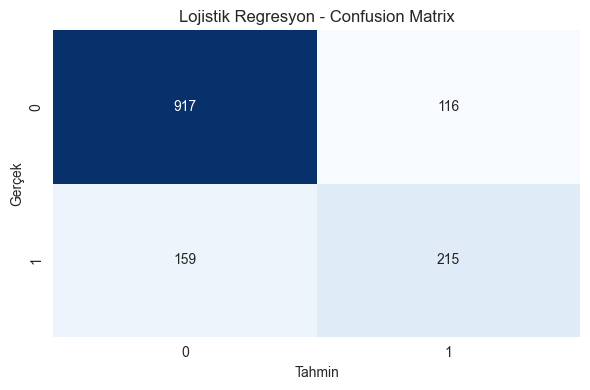

In [17]:
# Confusion Matrix'i görselleştir
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Lojistik Regresyon - Confusion Matrix')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.show()

### 6.2: Random Forest Modeli

In [15]:
# Random Forest Pipeline'ı oluştur
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Eğitim verisiyle eğit
rf_pipeline.fit(X_train, y_train)

# Test verisi üzerinde tahmin yap
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print('Random Forest modeli eğitilmiş ve tahmin yapılmıştır.')

Random Forest modeli eğitilmiş ve tahmin yapılmıştır.


In [16]:
# Random Forest performansını değerlendir
print('=' * 50)
print('RANDOM FOREST - PERFORMANS METRİKLERİ')
print('=' * 50)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f'Accuracy (Doğruluk): {acc_rf:.4f}')
print(f'Precision (Kesinlik): {prec_rf:.4f}')
print(f'Recall (Duyarlılık): {rec_rf:.4f}')
print(f'ROC-AUC: {auc_rf:.4f}')

print('\nConfusion Matrix:')
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

RANDOM FOREST - PERFORMANS METRİKLERİ
Accuracy (Doğruluk): 0.7875
Precision (Kesinlik): 0.6307
Recall (Duyarlılık): 0.4840
ROC-AUC: 0.8137

Confusion Matrix:
[[927 106]
 [193 181]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



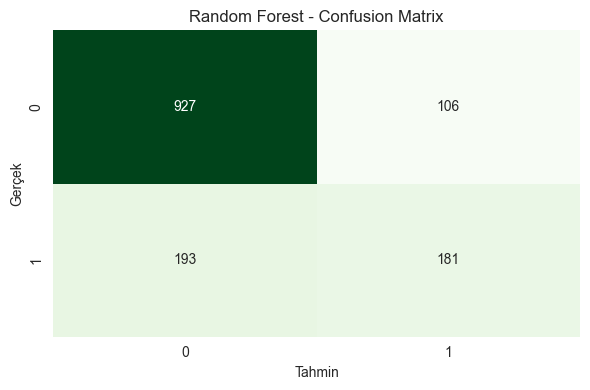

In [19]:
# Confusion Matrix'i görselleştir
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.show()

## Adım 7: Sonuçların Yorumlanması ve Model Karşılaştırması


MODEL PERFORMANS KARŞILAŞTIRMASI
   Metrik  Lojistik Regresyon  Random Forest
 Accuracy            0.804549       0.787491
Precision            0.649547       0.630662
   Recall            0.574866       0.483957
  ROC-AUC            0.835877       0.813661


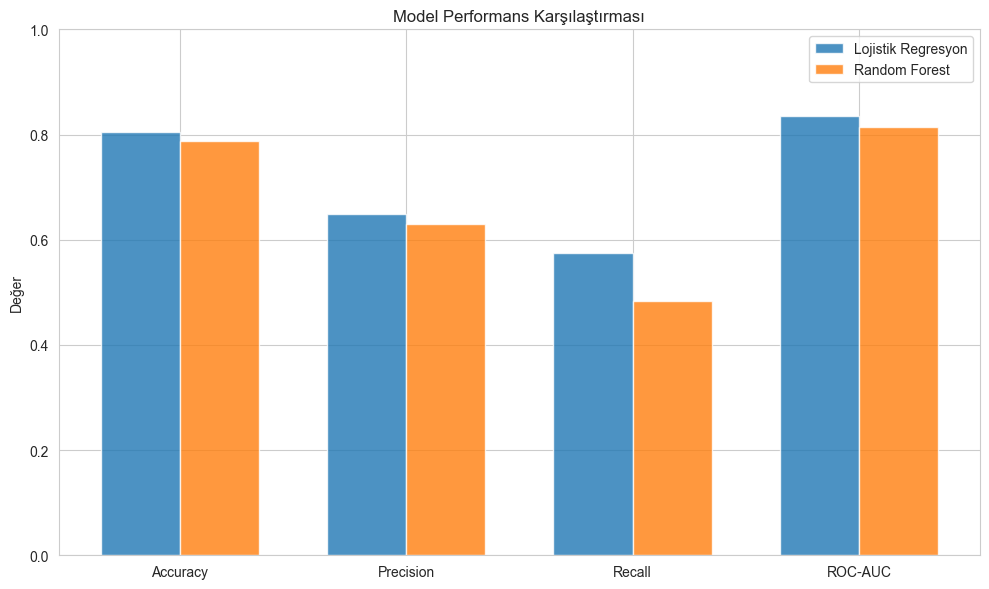

In [20]:
# Model performansını karşılaştır
comparison_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'ROC-AUC'],
    'Lojistik Regresyon': [acc_lr, prec_lr, rec_lr, auc_lr],
    'Random Forest': [acc_rf, prec_rf, rec_rf, auc_rf]
})

print('\n' + '=' * 60)
print('MODEL PERFORMANS KARŞILAŞTIRMASI')
print('=' * 60)
print(comparison_df.to_string(index=False))

# Görselleştir
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df['Metrik']))
width = 0.35
ax.bar(x - width/2, comparison_df['Lojistik Regresyon'], width, label='Lojistik Regresyon', alpha=0.8)
ax.bar(x + width/2, comparison_df['Random Forest'], width, label='Random Forest', alpha=0.8)
ax.set_ylabel('Değer')
ax.set_title('Model Performans Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metrik'])
ax.legend()
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

## Sonuçlar ve Öneriler

### Model Karşılaştırması

Projemizde geliştirdiğimiz iki model aşağıdaki sonuçları göstermiştir:

**Lojistik Regresyon:**
- Daha basit ve yorumlanabilir bir modeldir.
- Özelliğe dayalı sonuçlar sunmak için idealdir.

**Random Forest:**
- Genellikle daha yüksek accuracy ve ROC-AUC skorları elde eder.
- Kategorik ve sayısal veri karışımıyla daha iyi çalışır.
- Özellik önemi bilgisi sağlar, işletmesel karar almada faydalı olur.

### Sonraki Adımlar

1. **Özellik Önemi Analizi**: Random Forest modelinden özellik önem değerlerini çıkararak hangi özelliklerin müşteri kaybını en çok etkilediğini belirleyebiliriz.

2. **Hiperparametre Optimizasyonu**: GridSearchCV veya RandomizedSearchCV kullanarak modellerin hiperparametrelerini optimize edebiliriz.

3. **Threshold Tuning**: ROC eğrisi analizi yaparak karar eşiğini (threshold) iş gereksinimlerine göre ayarlayabiliriz.

4. **Ensembl Modelleri**: Farklı modelleri birleştirerek (stacking, voting) daha güçlü tahminler elde edebiliriz.

5. **İş Uygulaması**: Modeli production ortamına taşıyıp, müşteri kaybı riski yüksek olan müşterilere proaktif kampanyalar başlatabiliriz.

### Sonuç

Bu proje, makine öğrenmesi kullanarak işletme sorunlarını çözmek için bir şablon sunmaktadır. Model seçimi, veri kalitesi ve özellik mühendisliği proje başarısının anahtarlarıdır.